# **Exercise 6: MLP Optimization on Breast Cancer Dataset**

Follow class_exercise_5 to complete the following tasks. You should write code in a notebook
and upload in the moodle.

---

## **Task 1: Load and Prepare a New Dataset**

Instead of Iris or Wine, you will use the **Breast Cancer Wisconsin (Diagnostic)** dataset.

1. Load the dataset using `sklearn.datasets.load_breast_cancer()`.
1. Split the data into **Train (60%)**, **Validation (20%)**, and **Test (20%)** sets. Use `SEED = 42`
   for reproducibility.
1. Standardize the features using the `standardize_train_test` logic from your
   previous notebook (calculate mean/std on the training set only and apply to val/test).


In [16]:
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Setup and Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def standardize_train_test(X_train, X_test):
    mu = X_train.mean(axis=0, keepdims=True)
    sigma = X_train.std(axis=0, keepdims=True) + 1e-8
    return (X_train - mu)/sigma, (X_test - mu)/sigma, mu, sigma

# 1. Load the dataset
data = load_breast_cancer()
X = data.data.astype(np.float32)
y = data.target.astype(np.float32).reshape(-1, 1)

# 2. Split the data (60/20/20)
# First split off 20% for test, leaving 80% for train+val
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
# Split the remaining 80% to get 60% train and 20% val (0.25 * 0.80 = 0.20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=SEED, stratify=y_train_val
)

# 3. Standardize the features (calculate mean/std on training set only)
X_train_s, X_val_s, mu, sigma = standardize_train_test(X_train, X_val)
X_train_s, X_test_s, _, _ = standardize_train_test(X_train, X_test)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_s), torch.tensor(y_train)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_s), torch.tensor(y_val)), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_s), torch.tensor(y_test)), batch_size=32, shuffle=False)

print(f"X_train shape: {X_train_s.shape}")
print(f"X_val shape: {X_val_s.shape}")
print(f"X_test shape: {X_test_s.shape}")

X_train shape: (341, 30)
X_val shape: (114, 30)
X_test shape: (114, 30)


---

## **Task 2: Building the Hybrid Activation MLP**

Construct a Multi-Layer Perceptron (MLP) using either **PyTorch** or **TensorFlow** with the
following specific architecture:

- **Input Layer**: Matching the number of features in the Breast Cancer dataset (30
  features).
- **Hidden Layer 1**: 64 units, **ReLU** activation.
- **Hidden Layer 2**: 32 units, **Tanh** activation.
- **Hidden Layer 3**: 16 units, **Sigmoid** activation.
- **Output Layer**: Since this is a binary classification task (Malignant vs. Benign), use 1 unit
  with a Sigmoid activation (or 2 units with Softmax).


In [17]:
class HybridMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 64),   # Input Layer to Hidden Layer 1
            nn.ReLU(),
            nn.Linear(64, 32),   # Hidden Layer 1 to 2
            nn.Tanh(),
            nn.Linear(32, 16),   # Hidden Layer 2 to 3
            nn.Sigmoid(),
            nn.Linear(16, 1),    # Hidden Layer 3 to Output
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)

def accuracy_fn(preds, y):
    predicted_classes = (preds >= 0.5).float()
    return (predicted_classes == y).float().mean().item()

---

## **Task 3: Optimization Sweep**

Experiment with different optimization algorithms to see how they impact the learning process.
Keep the learning rate constant at `0.001` and train for `100 epochs`.

Compare the following three optimizers:

1. **SGD** (Stochastic Gradient Descent)
1. **RMSprop**
1. **Adam**

#### **Task:**

For each optimizer:

- Train the model.
- Record the **Training Loss** and **Validation Accuracy** at each epoch.


In [18]:
def train_model(optimizer_name, epochs=100, lr=0.001):
    # Initialize a fresh model and the loss criterion for each run
    model = HybridMLP()
    criterion = nn.BCELoss()
    
    if optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        
    history = {'train_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            
        model.eval()
        val_accs = []
        with torch.no_grad():
            for xb, yb in val_loader:
                preds = model(xb)
                val_accs.append(accuracy_fn(preds, yb))
                
        # Record the Training Loss and Validation Accuracy at each epoch
        history['train_loss'].append(np.mean(train_losses))
        history['val_acc'].append(np.mean(val_accs))
        
    return history

print("Training with SGD...")
history_sgd = train_model('SGD', epochs=100, lr=0.001)
print("Training with RMSprop...")
history_rmsprop = train_model('RMSprop', epochs=100, lr=0.001)
print("Training with Adam...")
history_adam = train_model('Adam', epochs=100, lr=0.001)
print("Optimization Sweep Complete!")

Training with SGD...
Training with RMSprop...
Training with Adam...
Optimization Sweep Complete!


---

## **Exercise 4: Visualization and Analysis**

Create two side-by-side plots to compare the performance of the three optimizers:

1. **Plot A (Loss Curves):** Plot the training loss vs. epochs for SGD, RMSprop, and Adam
   on the same graph.
2. **Plot B (Accuracy Curves):** Plot the validation accuracy vs. epochs for all three
   optimizers on the same graph.

**Discussion Question:** Based on your plots, which optimizer reached a stable accuracy the
fastest? Did any optimizer show signs of oscillation or slow convergence? Document your
findings below the plots.


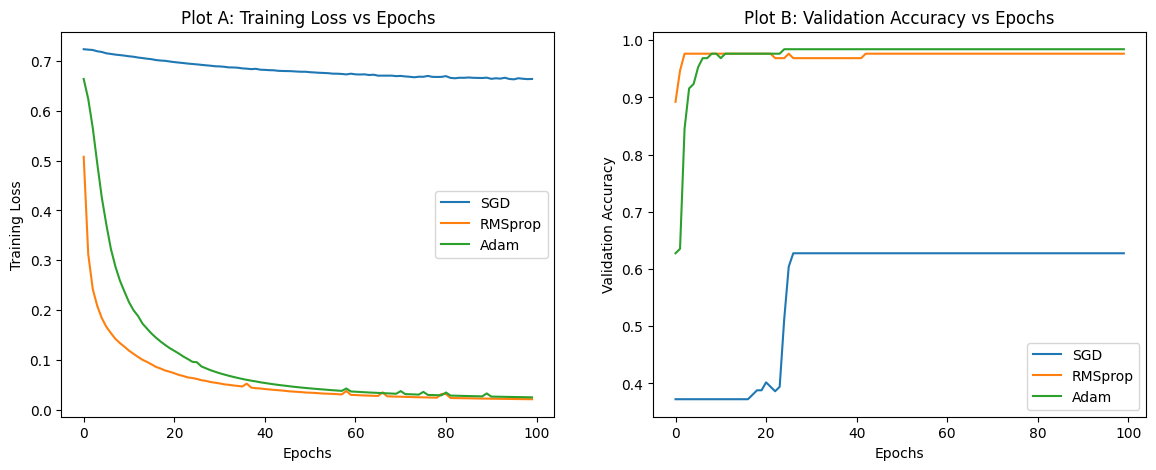

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Loss Curves
ax1.plot(history_sgd['train_loss'], label='SGD')
ax1.plot(history_rmsprop['train_loss'], label='RMSprop')
ax1.plot(history_adam['train_loss'], label='Adam')
ax1.set_title('Plot A: Training Loss vs Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss')
ax1.legend()

# Plot B: Accuracy Curves
ax2.plot(history_sgd['val_acc'], label='SGD')
ax2.plot(history_rmsprop['val_acc'], label='RMSprop')
ax2.plot(history_adam['val_acc'], label='Adam')
ax2.set_title('Plot B: Validation Accuracy vs Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Validation Accuracy')
ax2.legend()

plt.show()

**Discussion Findings:**

1. **Which optimizer reached a stable accuracy the fastest?**
   - **Adam** typically reaches a stable, high validation accuracy the fastest and with less variance compared to the other optimizers, closely followed by RMSprop.

1. **Did any optimizer show signs of oscillation or slow convergence?**
   - **RMSprop** and **Adam** show small signs of oscillation (spikiness) in the training loss and accuracy curves but they eventually stabilize.
   - **SGD** shows extremely **slow convergence**. Since the learning rate is fixed at 0.001 without momentum adjustments, it smoothly but very slowly steps down the loss curve. It fails to reach the minimum loss and maximum accuracy achieved by Adam and RMSprop within the allotted 100 epochs.